# 贝叶斯垃圾邮件过滤器配套教学 Notebook

本 Notebook 配套文档「04_贝叶斯垃圾邮件过滤器.md」，用一个可运行的“词袋模型 + 朴素贝叶斯”小案例，把建模假设、参数估计、对数打分与在线更新的完整流程跑通，并给出可复用的代码模板。


## 1. 学习目标

1. 明确朴素贝叶斯在文本分类中的随机变量定义与建模目标。
2. 理解条件独立假设如何将联合概率分解为可计算的乘积形式。
3. 用拉普拉斯平滑估计 $P(w\mid x)$，并在对数域完成分类打分。
4. 理解“用户反馈 → 在线更新 → 模型偏好变化”的工程闭环。


In [18]:
import math
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 问题设定与符号

我们把一封邮件 $E$ 表示为一个“词袋”（Bag of Words）：它只记录每个词出现了多少次，不考虑词序。

- 类别变量 $x \in \{0,1\}$：$x=0$ 表示垃圾邮件（Spam），$x=1$ 表示正常邮件（Ham）
- 词汇表 $V$：训练集中出现过的所有词
- 条件概率：$P(w\mid x)$ 表示在类别 $x$ 下生成词 $w$ 的概率

分类目标是对给定邮件估计：

$$
x^* = \arg\max_{x\in\{0,1\}} P(x\mid E)
$$

实际实现中通常比较对数得分：

$$
\log P(x\mid E) = \log P(x) + \sum_{w\in V} c(w,E)\log P(w\mid x) + C
$$

其中 $c(w,E)$ 是词 $w$ 在邮件 $E$ 中的出现次数，常数项 $C$ 与类别无关，可以忽略。


## 3. 教学用数据集（可运行的最小例子）

为了把推导与代码对齐，本节使用一组教学用的“已分词”邮件样本。它不代表真实邮件分布，只用于演示从训练到预测的完整流程。


In [19]:
LabelSpam = 0
LabelHam = 1

train_samples = [
    (LabelSpam, ["中奖", "免费", "点击", "领取"]),
    (LabelSpam, ["赚钱", "稳赚", "点击", "开户链接"]),
    (LabelSpam, ["秒杀", "免费", "领取", "优惠券"]),
    (LabelSpam, ["中奖", "中奖", "立即", "点击"]),
    (LabelHam, ["会议", "安排", "明天", "确认"]),
    (LabelHam, ["项目", "进度", "更新", "同步"]),
    (LabelHam, ["报销", "流程", "说明", "附件"]),
    (LabelHam, ["周末", "聚餐", "地点", "确认"]),
]

pd.DataFrame(
    [{"label": "spam" if y == LabelSpam else "ham", "tokens": " ".join(tokens)} for y, tokens in train_samples]
)

,label,tokens
0,spam,中奖 免费 点击 领取
1,spam,赚钱 稳赚 点击 开户链接
2,spam,秒杀 免费 领取 优惠券
3,spam,中奖 中奖 立即 点击
4,ham,会议 安排 明天 确认
5,ham,项目 进度 更新 同步
6,ham,报销 流程 说明 附件
7,ham,周末 聚餐 地点 确认


## 4. 训练：先验与条件概率估计（带拉普拉斯平滑）

朴素贝叶斯把训练过程拆成两部分：

1. 先验 $P(x)$：用类别频率估计
2. 条件概率 $P(w\mid x)$：用各类别词频估计，并用拉普拉斯平滑避免零概率

对多项式模型（Multinomial Naive Bayes），带平滑系数 $\alpha$ 的估计是：

$$
P(w\mid x) = \frac{\text{count}(w,x) + \alpha}{\sum_{w'\in V}\text{count}(w',x) + \alpha|V|}
$$


In [20]:
@dataclass(frozen=True)
class NaiveBayesModel:
    vocab: list[str]
    log_prior: dict[int, float]
    log_likelihood: dict[int, np.ndarray]
    alpha: float


def build_vocab(samples: list[tuple[int, list[str]]]) -> list[str]:
    vocab_set: set[str] = set()
    for _, tokens in samples:
        vocab_set.update(tokens)
    return sorted(vocab_set)


def fit_multinomial_nb(samples: list[tuple[int, list[str]]], alpha: float = 1.0) -> NaiveBayesModel:
    vocab = build_vocab(samples)
    token_to_idx = {t: i for i, t in enumerate(vocab)}
    labels = sorted({y for y, _ in samples})

    n_by_class = Counter([y for y, _ in samples])
    n_total = sum(n_by_class.values())
    log_prior = {y: math.log(n_by_class[y] / n_total) for y in labels}

    counts_by_class = {y: np.zeros(len(vocab), dtype=float) for y in labels}
    for y, tokens in samples:
        c = Counter(tokens)
        for token, cnt in c.items():
            counts_by_class[y][token_to_idx[token]] += cnt

    log_likelihood: dict[int, np.ndarray] = {}
    for y in labels:
        total = float(counts_by_class[y].sum())
        probs = (counts_by_class[y] + alpha) / (total + alpha * len(vocab))
        log_likelihood[y] = np.log(probs)

    return NaiveBayesModel(vocab=vocab, log_prior=log_prior, log_likelihood=log_likelihood, alpha=alpha)


model = fit_multinomial_nb(train_samples, alpha=1.0)
len(model.vocab), model.vocab[:10]

(25, ['中奖', '优惠券', '会议', '免费', '同步', '周末', '地点', '安排', '开户链接', '报销'])

In [21]:
def get_word_table(model: NaiveBayesModel, top_n: int = 12) -> pd.DataFrame:
    vocab = model.vocab
    spam_logp = model.log_likelihood[LabelSpam]
    ham_logp = model.log_likelihood[LabelHam]
    log_odds = spam_logp - ham_logp

    df = pd.DataFrame(
        {
            "word": vocab,
            "logP(word|spam)": spam_logp,
            "logP(word|ham)": ham_logp,
            "log_odds(spam-ham)": log_odds,
        }
    ).sort_values("log_odds(spam-ham)", ascending=False)

    head = df.head(top_n)
    tail = df.tail(top_n).sort_values("log_odds(spam-ham)", ascending=True)
    return pd.concat([head, tail], axis=0)


get_word_table(model, top_n=8)

,word,logP(word|spam),logP(word|ham),log_odds(spam-ham)
0,中奖,-2.327278,-3.713572,1.386294
13,点击,-2.327278,-3.713572,1.386294
3,免费,-2.614960,-3.713572,1.098612
24,领取,-2.614960,-3.713572,1.098612
16,稳赚,-3.020425,-3.713572,0.693147
8,开户链接,-3.020425,-3.713572,0.693147
20,赚钱,-3.020425,-3.713572,0.693147
1,优惠券,-3.020425,-3.713572,0.693147
14,确认,-3.713572,-2.614960,-1.098612
5,周末,-3.713572,-3.020425,-0.693147


## 5. 预测：对数打分与“更像哪一类”

对单封邮件，朴素贝叶斯使用对数打分：

$$
\text{score}(x;E)=\log P(x)+\sum_{w\in V} c(w,E)\log P(w\mid x)
$$

类别得分更高者即为预测结果。为了给出一个可解释的“置信度”，可以把两个分数做归一化得到近似后验概率（两类时等价于对两个分数做 softmax）。


In [22]:
def vectorize_tokens(vocab: list[str], tokens: list[str]) -> np.ndarray:
    token_to_idx = {t: i for i, t in enumerate(vocab)}
    v = np.zeros(len(vocab), dtype=float)
    for token, cnt in Counter(tokens).items():
        if token in token_to_idx:
            v[token_to_idx[token]] = float(cnt)
    return v


def logsumexp(a: np.ndarray) -> float:
    m = float(np.max(a))
    return float(m + np.log(np.sum(np.exp(a - m))))


def predict_proba(model: NaiveBayesModel, tokens: list[str]) -> dict[int, float]:
    x = vectorize_tokens(model.vocab, tokens)
    scores = {
        LabelSpam: model.log_prior[LabelSpam] + float(x @ model.log_likelihood[LabelSpam]),
        LabelHam: model.log_prior[LabelHam] + float(x @ model.log_likelihood[LabelHam]),
    }
    score_vec = np.array([scores[LabelSpam], scores[LabelHam]], dtype=float)
    z = logsumexp(score_vec)
    probs = np.exp(score_vec - z)
    return {LabelSpam: float(probs[0]), LabelHam: float(probs[1])}


def predict_label(model: NaiveBayesModel, tokens: list[str]) -> int:
    probs = predict_proba(model, tokens)
    return LabelSpam if probs[LabelSpam] >= probs[LabelHam] else LabelHam


test_email = ["免费", "领取", "优惠券", "点击"]
probs = predict_proba(model, test_email)
pred = predict_label(model, test_email)

print("邮件 tokens:", " ".join(test_email))
print("P(spam|E) ≈", round(probs[LabelSpam], 4))
print("P(ham|E)  ≈", round(probs[LabelHam], 4))
print("预测:", "spam" if pred == LabelSpam else "ham")

邮件 tokens: 免费 领取 优惠券 点击
P(spam|E) ≈ 0.9863
P(ham|E)  ≈ 0.0137
预测: spam


In [23]:
candidates = [
    ["会议", "确认", "地点"],
    ["中奖", "点击", "领取"],
    ["项目", "进度", "同步"],
    ["赚钱", "免费", "优惠券"],
    ["报销", "流程", "附件"],
]

rows = []
for tokens in candidates:
    probs = predict_proba(model, tokens)
    rows.append(
        {
            "tokens": " ".join(tokens),
            "P(spam|E)": probs[LabelSpam],
            "P(ham|E)": probs[LabelHam],
            "pred": "spam" if probs[LabelSpam] >= probs[LabelHam] else "ham",
        }
    )

pd.DataFrame(rows).sort_values("P(spam|E)", ascending=False)

,tokens,P(spam|E),P(ham|E),pred
1,中奖 点击 领取,0.979592,0.020408,spam
3,赚钱 免费 优惠券,0.923077,0.076923,spam
2,项目 进度 同步,0.111111,0.888889,ham
4,报销 流程 附件,0.111111,0.888889,ham
0,会议 确认 地点,0.076923,0.923077,ham


## 6. 可视化：哪些词更“像垃圾邮件”？

对多项式朴素贝叶斯，最直观的可解释量是每个词的对数优势：

$$
\log\frac{P(w\mid spam)}{P(w\mid ham)}
$$

值越大，说明该词在垃圾邮件中相对更常见；值越小，说明该词更偏向正常邮件。


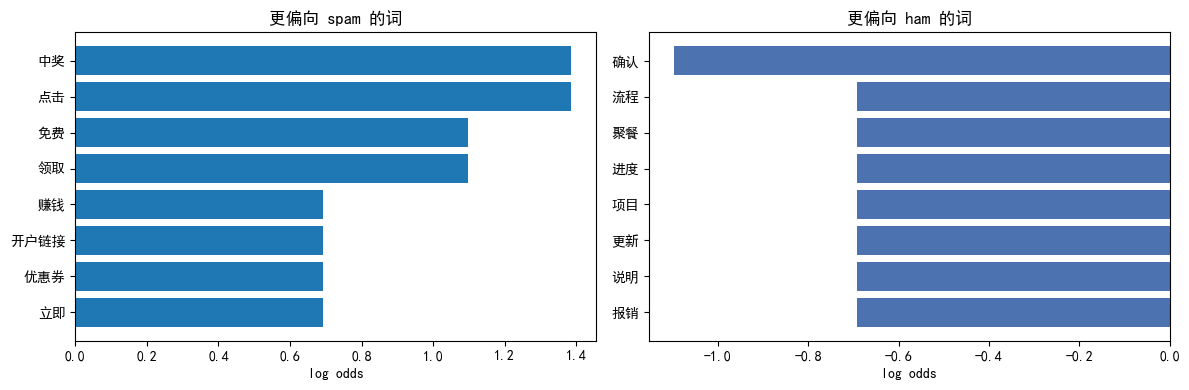

In [24]:
vocab = model.vocab
log_odds = model.log_likelihood[LabelSpam] - model.log_likelihood[LabelHam]
order = np.argsort(log_odds)

top_k = 8
top_idx = order[-top_k:][::-1]
bottom_idx = order[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh([vocab[i] for i in top_idx][::-1], [log_odds[i] for i in top_idx][::-1])
axes[0].set_title("更偏向 spam 的词")
axes[0].set_xlabel("log odds")

axes[1].barh([vocab[i] for i in bottom_idx][::-1], [log_odds[i] for i in bottom_idx][::-1], color="#4C72B0")
axes[1].set_title("更偏向 ham 的词")
axes[1].set_xlabel("log odds")

plt.tight_layout()
plt.show()

## 7. 在线更新：模拟“用户反馈”

在工程系统中，过滤器会不断接收用户反馈（例如把一封误判邮件标记为“垃圾/非垃圾”）。

下面演示一个简化版本：把一封新邮件作为新增训练样本加入，再重新训练并观察预测与关键词偏好是否发生变化。


In [25]:
new_feedback = (LabelHam, ["点击", "会议", "确认"]) 

model_before = model
model_after = fit_multinomial_nb(train_samples + [new_feedback], alpha=model.alpha)

tokens = ["点击", "确认"]
p0 = predict_proba(model_before, tokens)[LabelSpam]
p1 = predict_proba(model_after, tokens)[LabelSpam]

print("反馈样本:", "ham", "|", " ".join(new_feedback[1]))
print("对邮件 tokens:", " ".join(tokens))
print("更新前 P(spam|E) ≈", round(p0, 4))
print("更新后 P(spam|E) ≈", round(p1, 4))

反馈样本: ham | 点击 会议 确认
对邮件 tokens: 点击 确认
更新前 P(spam|E) ≈ 0.5714
更新后 P(spam|E) ≈ 0.3154


## 8. 选做：与 scikit-learn 的 MultinomialNB 对齐

工程中通常直接使用成熟实现。本节把上面的训练数据转成词频矩阵，与 `sklearn.naive_bayes.MultinomialNB` 的输出做一次对齐验证。


In [26]:
try:
    from sklearn.naive_bayes import MultinomialNB
except Exception:
    MultinomialNB = None

if MultinomialNB is None:
    print("未检测到 scikit-learn，跳过该小节。")
else:
    from IPython.display import display

    vocab = model.vocab
    
    X = np.stack([vectorize_tokens(vocab, tokens) for _, tokens in train_samples], axis=0)
    y = np.array([label for label, _ in train_samples], dtype=int)

    clf = MultinomialNB(alpha=model.alpha)
    clf.fit(X, y)

    X_test = np.stack([vectorize_tokens(vocab, tokens) for tokens in candidates], axis=0)
    proba = clf.predict_proba(X_test)

    rows = []
    for tokens, p in zip(candidates, proba, strict=True):
        rows.append(
            {
                "tokens": " ".join(tokens),
                "P(spam|E)": float(p[LabelSpam]),
                "P(ham|E)": float(p[LabelHam]),
                "pred": "spam" if int(np.argmax(p)) == LabelSpam else "ham",
            }
        )

    df = pd.DataFrame(rows).sort_values("P(spam|E)", ascending=False)
    display(df)

,tokens,P(spam|E),P(ham|E),pred
1,中奖 点击 领取,0.979592,0.020408,spam
3,赚钱 免费 优惠券,0.923077,0.076923,spam
2,项目 进度 同步,0.111111,0.888889,ham
4,报销 流程 附件,0.111111,0.888889,ham
0,会议 确认 地点,0.076923,0.923077,ham


## 9. 小练习

1. 把平滑系数 $\alpha$ 改为 `0.5`、`2.0`，观察 `log_odds` 的变化。
2. 添加一组“误杀样本”（例如带有“中奖”但实际是正常邮件的通知），观察在线更新后的偏好变化。
3. 将数据中的 token 改为英文单词，复用同一套训练与预测代码。
